# Chapter 6: The first fundamental form

Source orientation: printed pages 121-158; PDF pages 127-163; sections 6.1-6.5.

This notebook is an original standalone teaching pass over Chapter 6. The local PDF was used only to orient the span, terminology, and order of ideas; the prose, code, diagrams, and checks here are new.

## Chapter Question

How much of surface geometry can be read from the quadratic expression

$$ds^2 = E\,du^2 + 2F\,du\,dv + G\,dv^2?$$

Chapter 6 answers this by treating the first fundamental form as the local measuring device for tangent-vector length, curve length, angle, area density, local isometry, conformality, equiareality, Archimedes' sphere-cylinder theorem, and the metric rules of spherical geometry.

## Computational Translation Guide

| Book-side idea | Computational object in this notebook | Check to keep honest |
| --- | --- | --- |
| First fundamental form | Gram matrix `[[E, F], [F, G]]` from the two patch derivatives | positive determinant and `||sigma_u x sigma_v||^2 = EG - F^2` |
| Length of a surface curve | integral of `sqrt([u_dot, v_dot] M [u_dot, v_dot])` | coordinate formula agrees with direct 3D speed |
| Local isometry | two pulled-back Gram matrices are equal | plane strip and cylinder patch both have `I` |
| Conformal map | pulled-back Gram matrix is a scalar multiple of the original | stereographic metric is `lambda(u,v) I` |
| Equiareal map | determinants of the two Gram matrices agree | Archimedes sphere/cylinder area densities match |
| Spherical distance | `arccos(p dot q)` on the unit sphere | stereographic half-angle distance formula agrees |
| Spherical triangle | side lengths from dot products; angles from tangent directions | cosine rule, sine rule, and spherical excess residuals |

## Route

1. Build the metric coefficients and show how they act as local rulers.
2. Measure surface curves and test the cylinder wrap as a local isometry.
3. Separate isometry, conformality, and equiareality by comparing metric matrices.
4. Visualize Archimedes' sphere-to-cylinder area preservation.
5. Use the same metric language to compute spherical distance and triangle laws.
6. Run a small applied lab that classifies maps from their metric data.


In [1]:
from pathlib import Path
import sys

START = Path.cwd().resolve()
search_roots = [START, *START.parents]
search_roots.extend([START / "Elementary-Differential-Geometry-Andrew-Pressley"])

BOOK_ROOT = None
for candidate in search_roots:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not find the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

UNIT = "chapter-06"
NOTEBOOK_PATH = BOOK_ROOT / "chapter-06-the-first-fundamental-form" / "06-the-first-fundamental-form.ipynb"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
FIGURES = UNIT_ARTIFACT_ROOT / "figures"
INTERACTIVE = UNIT_ARTIFACT_ROOT / "interactive"
CHECKS = UNIT_ARTIFACT_ROOT / "checks"
TABLES = UNIT_ARTIFACT_ROOT / "tables"
for folder in [FIGURES, INTERACTIVE, CHECKS, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)

from utils.artifacts import assert_artifact, display_artifact

BOOK_ROOT


WindowsPath('D:/Geometry/Elementary-Differential-Geometry-Andrew-Pressley')

## Standalone Reading Guide

The first fundamental form is the chapter's main translation device. A surface patch begins as a parametrized map into three-dimensional space, but its intrinsic measurements are carried by the three metric coefficients E, F, and G. Those coefficients tell a notebook, and a geometer, how a tiny coordinate displacement turns into actual length and angle on the surface. Once that metric ledger is available, many questions no longer need the surrounding embedding: curve length, angle, area, conformality, and local isometry can all be checked from the quadratic form.

Read the visual sequence as a narrowing of what must be preserved. The metric-coefficient figures show how coordinate rulers stretch and shear. The cylinder example checks a local isometry: the surface bends in space while the metric data stay unchanged. The stereographic panel highlights a different preservation rule, conformality, where angles survive but scale changes point by point. The equiareal and Archimedes sections ask for preservation of area instead. The spherical triangle section then uses the metric to compute distances and angles on a curved surface where Euclidean straight-line intuition fails.

The applied classifier is deliberately computational. It asks whether a proposed map is metric-preserving, angle-preserving, or area-preserving by checking the induced coefficients rather than by relying on the look of the picture. Those checks are the chapter's habit in miniature: translate geometry into E, F, G, compute the invariant, and then interpret what kind of geometry the map respects.


## Library Choices

This chapter is about a metric on surfaces, so the notebook uses:

- `numpy` for sampled surface patches, dot products, metric matrices, and numerical quadrature.
- `matplotlib` for durable static geometry diagrams: local metric ellipses, curve lengths, conformal scale, Archimedes bands, and spherical triangles.
- `plotly` for an interactive cylinder-wrap surface view where rotation makes the local isometry inspectable.
- `sympy` for the exact algebraic identity behind the area element.
- `pandas` only for compact lab tables.

These choices follow the geometry library catalog: 2D proof/metric diagrams use Matplotlib, rotatable surface comparison uses Plotly, and exact metric identities use SymPy.


In [2]:
import json
import math

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import plotly.graph_objects as go
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SOURCE_SPAN = {
    "printed_pages": "121-158",
    "pdf_pages": "127-163",
    "sections": "6.1-6.5",
    "source_use": "orientation only; no copied prose, figures, screenshots, hints, or solutions",
}

STORYBOARD = {
    "chapter_goal": "Use the first fundamental form as a computational measuring device for length, angle, area, and spherical geometry.",
    "visual_sequence": [
        {
            "concept": "metric coefficients E,F,G",
            "artifact": "figures/metric-coefficients-rulers.png",
            "representation": "unit-speed ellipses, coefficient curves, and area density comparison",
            "library": "matplotlib + numpy",
            "inspection_target": "changing G changes allowable coordinate velocity and local area density",
            "validation": "positive determinant and sampled metric table",
        },
        {
            "concept": "lengths and local isometry",
            "artifact": "figures/surface-curve-lengths-and-cylinder-isometry.png; interactive/local-isometry-cylinder-wrap.html",
            "representation": "same parameter curve in a plane strip and wrapped cylinder",
            "library": "matplotlib + plotly",
            "inspection_target": "the curve bends in space but the metric length is unchanged",
            "validation": "plane and cylinder curve-length residual",
        },
        {
            "concept": "conformal maps",
            "artifact": "figures/stereographic-conformal-factor.png",
            "representation": "stereographic conformal scale field and local angle test",
            "library": "matplotlib + numpy",
            "inspection_target": "angles survive while scale varies with radius",
            "validation": "metric equals lambda times identity",
        },
        {
            "concept": "equiareal maps and Archimedes theorem",
            "artifact": "figures/archimedes-equiareal-bands.png",
            "representation": "sphere band and matching cylinder band",
            "library": "matplotlib + numpy",
            "inspection_target": "sphere and cylinder area densities both equal cos(theta)",
            "validation": "determinants of the pulled-back metrics agree",
        },
        {
            "concept": "spherical distance and triangles",
            "artifact": "figures/spherical-distance-triangle.png",
            "representation": "great-circle triangle plus stereographic distance sample",
            "library": "matplotlib + numpy",
            "inspection_target": "side lengths are central angles and area is angular excess",
            "validation": "cosine rule, sine rule, excess, and stereographic distance residuals",
        },
    ],
}


def write_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return path


source_span_path = write_json(CHECKS / "source-span.json", SOURCE_SPAN)
storyboard_path = write_json(CHECKS / "visual-storyboard.json", STORYBOARD)


def metric_matrix(E, F, G):
    return np.array([[float(E), float(F)], [float(F), float(G)]], dtype=float)


def metric_from_partials(sigma_u, sigma_v):
    sigma_u = np.asarray(sigma_u, dtype=float)
    sigma_v = np.asarray(sigma_v, dtype=float)
    E = float(np.dot(sigma_u, sigma_u))
    F = float(np.dot(sigma_u, sigma_v))
    G = float(np.dot(sigma_v, sigma_v))
    return metric_matrix(E, F, G)


def speed_from_metric(M, uv_dot):
    uv_dot = np.asarray(uv_dot, dtype=float)
    return float(np.sqrt(uv_dot @ M @ uv_dot))


def area_density(M):
    return float(np.sqrt(np.linalg.det(M)))


def angle_from_metric(M, a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    numerator = a @ M @ b
    denominator = math.sqrt(a @ M @ a) * math.sqrt(b @ M @ b)
    return float(np.arccos(np.clip(numerator / denominator, -1.0, 1.0)))


source_span_path, storyboard_path


(WindowsPath('D:/Geometry/Elementary-Differential-Geometry-Andrew-Pressley/artifacts/chapter-06/checks/source-span.json'),
 WindowsPath('D:/Geometry/Elementary-Differential-Geometry-Andrew-Pressley/artifacts/chapter-06/checks/visual-storyboard.json'))

## Metric Coefficients As Local Rulers

For a patch `sigma(u,v)`, the vectors `sigma_u` and `sigma_v` span the tangent plane. Their dot products form the Gram matrix

$$M = \begin{pmatrix}E&F\\F&G\end{pmatrix}.$$

The expression `[u_dot, v_dot] M [u_dot, v_dot]^T` is the squared physical speed of the surface curve. The area density is `sqrt(det(M)) = sqrt(EG-F^2)`. The figure below shows three ways to inspect this: unit-speed ellipses in coordinate-velocity space, the changing `G` coefficient on the sphere, and the area density used later by Archimedes' map.


,patch,theta,v_or_radius,E,F,G,area_density
0,unit sphere latitude-longitude,-1.10,NaN,1.000000,0.0,0.205749,0.453596
1,Archimedes cylinder coordinates,-1.10,NaN,0.205749,0.0,1.000000,0.453596
2,unit sphere latitude-longitude,-0.55,NaN,1.000000,0.0,0.726798,0.852525
3,Archimedes cylinder coordinates,-0.55,NaN,0.726798,0.0,1.000000,0.852525
4,unit sphere latitude-longitude,0.00,NaN,1.000000,0.0,1.000000,1.000000
5,Archimedes cylinder coordinates,0.00,NaN,1.000000,0.0,1.000000,1.000000
6,unit sphere latitude-longitude,0.55,NaN,1.000000,0.0,0.726798,0.852525
7,Archimedes cylinder coordinates,0.55,NaN,0.726798,0.0,1.000000,0.852525


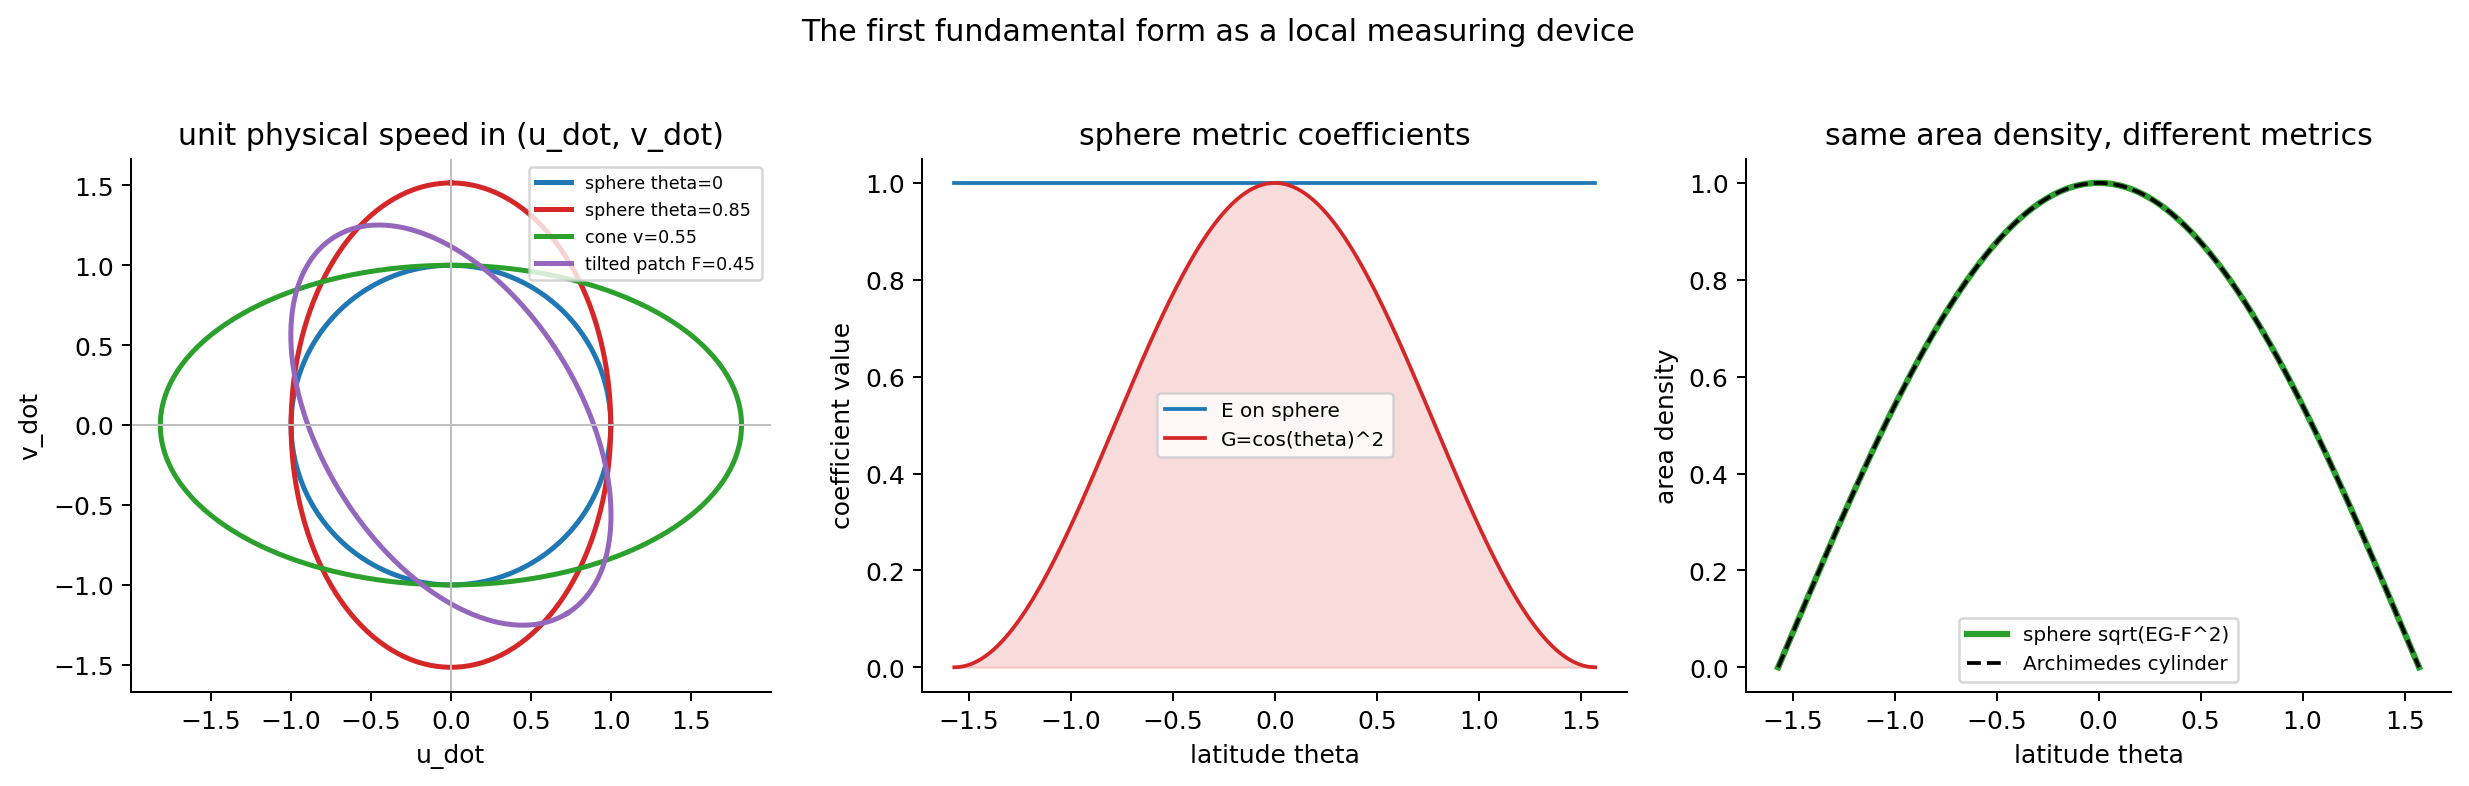

In [3]:
a1, a2, a3, b1, b2, b3 = sp.symbols("a1 a2 a3 b1 b2 b3", real=True)
a = sp.Matrix([a1, a2, a3])
b = sp.Matrix([b1, b2, b3])
area_identity = sp.simplify((a.dot(a) * b.dot(b) - a.dot(b) ** 2) - a.cross(b).dot(a.cross(b)))
assert area_identity == 0

metric_rows = []
for theta in np.linspace(-1.1, 1.1, 5):
    c = float(np.cos(theta))
    metric_rows.append({
        "patch": "unit sphere latitude-longitude",
        "theta": theta,
        "v_or_radius": np.nan,
        "E": 1.0,
        "F": 0.0,
        "G": c * c,
        "area_density": abs(c),
    })
    metric_rows.append({
        "patch": "Archimedes cylinder coordinates",
        "theta": theta,
        "v_or_radius": np.nan,
        "E": c * c,
        "F": 0.0,
        "G": 1.0,
        "area_density": abs(c),
    })
for radius in [0.5, 1.0, 1.8]:
    metric_rows.append({
        "patch": "generalized cone normalized form",
        "theta": np.nan,
        "v_or_radius": radius,
        "E": radius * radius,
        "F": 0.0,
        "G": 1.0,
        "area_density": radius,
    })
metric_rows.append({
    "patch": "plane and cylinder wrap",
    "theta": np.nan,
    "v_or_radius": np.nan,
    "E": 1.0,
    "F": 0.0,
    "G": 1.0,
    "area_density": 1.0,
})
metric_table = pd.DataFrame(metric_rows)
metric_csv_path = TABLES / "metric-samples.csv"
metric_table.to_csv(metric_csv_path, index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

ellipse_specs = [
    ("sphere theta=0", metric_matrix(1, 0, 1), "#1f77b4"),
    ("sphere theta=0.85", metric_matrix(1, 0, np.cos(0.85) ** 2), "#d62728"),
    ("cone v=0.55", metric_matrix(0.55 ** 2, 0, 1), "#2ca02c"),
    ("tilted patch F=0.45", metric_matrix(1.25, 0.45, 0.8), "#9467bd"),
]
ax = axes[0]
t = np.linspace(0, 2 * np.pi, 300)
for label, M, color in ellipse_specs:
    eigvals, eigvecs = np.linalg.eigh(M)
    circle = np.vstack([np.cos(t), np.sin(t)])
    ellipse = eigvecs @ np.diag(1 / np.sqrt(eigvals)) @ circle
    ax.plot(ellipse[0], ellipse[1], color=color, lw=2, label=label)
ax.axhline(0, color="0.75", lw=0.8)
ax.axvline(0, color="0.75", lw=0.8)
ax.set_aspect("equal")
ax.set_title("unit physical speed in (u_dot, v_dot)")
ax.set_xlabel("u_dot")
ax.set_ylabel("v_dot")
ax.legend(fontsize=7, loc="upper right")

ax = axes[1]
theta_grid = np.linspace(-np.pi / 2, np.pi / 2, 300)
G_sphere = np.cos(theta_grid) ** 2
ax.plot(theta_grid, np.ones_like(theta_grid), label="E on sphere", color="#1f77b4")
ax.plot(theta_grid, G_sphere, label="G=cos(theta)^2", color="#d62728")
ax.fill_between(theta_grid, 0, G_sphere, color="#d62728", alpha=0.16)
ax.set_title("sphere metric coefficients")
ax.set_xlabel("latitude theta")
ax.set_ylabel("coefficient value")
ax.legend(fontsize=8)

ax = axes[2]
area_sphere = np.abs(np.cos(theta_grid))
area_cylinder = np.abs(np.cos(theta_grid))
ax.plot(theta_grid, area_sphere, color="#2ca02c", lw=2.5, label="sphere sqrt(EG-F^2)")
ax.plot(theta_grid, area_cylinder, color="black", ls="--", lw=1.5, label="Archimedes cylinder")
ax.set_title("same area density, different metrics")
ax.set_xlabel("latitude theta")
ax.set_ylabel("area density")
ax.legend(fontsize=8)

fig.suptitle("The first fundamental form as a local measuring device", y=1.03)
fig.tight_layout()
metric_fig_path = FIGURES / "metric-coefficients-rulers.png"
fig.savefig(metric_fig_path, bbox_inches="tight")
plt.close(fig)

display(metric_table.head(8))
display_artifact(metric_fig_path, width=1000)


## Lengths Of Surface Curves

A curve on a patch is a pair of coordinate functions `u(t), v(t)`. The first fundamental form turns the coordinate velocity into physical speed:

$$L = \int \sqrt{E\dot u^2 + 2F\dot u\dot v + G\dot v^2}\,dt.$$

The cylinder wrap is the cleanest local-isometry test in this chapter. The plane strip `(u,v)` and the cylinder `(cos u, sin u, v)` have the same metric matrix `I`, so every coordinate curve has the same computed length before and after wrapping, even though it looks spatially different.


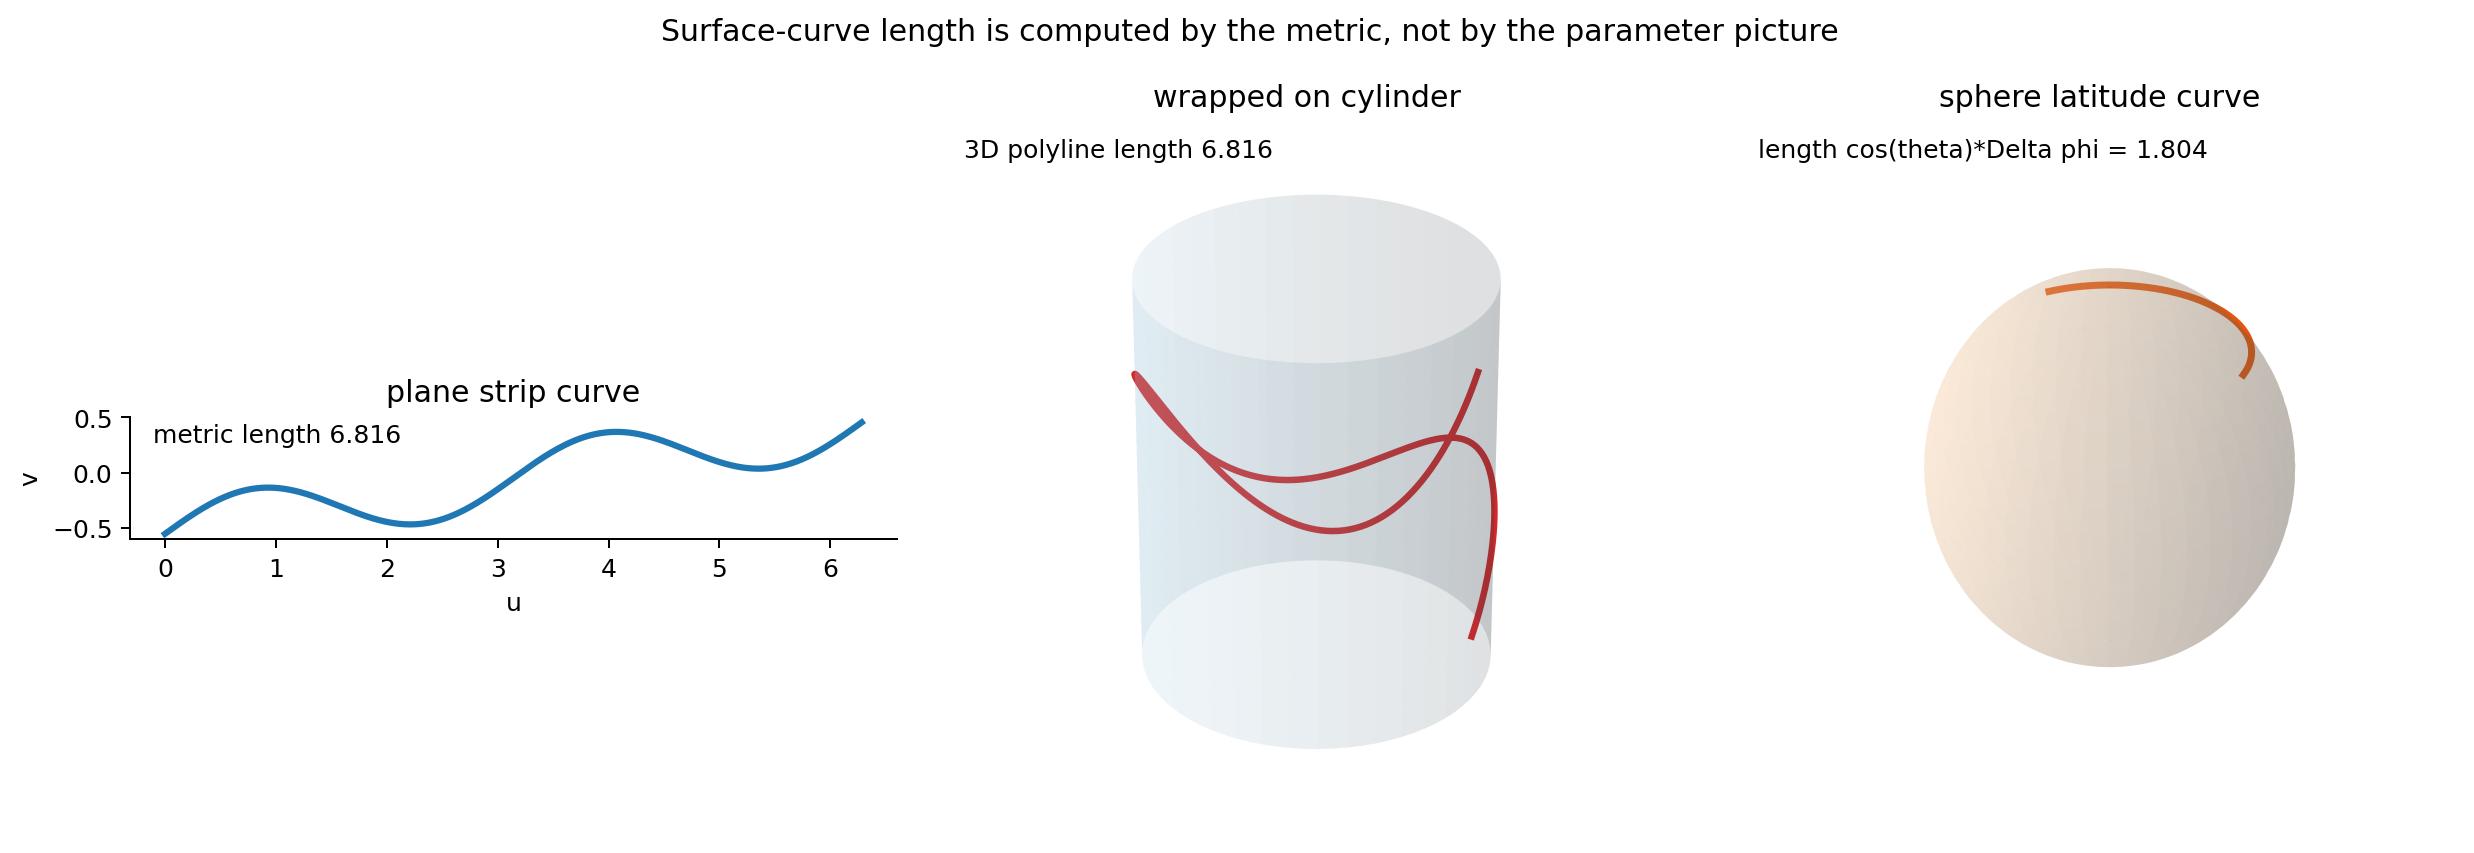

{'plane_metric_length': 6.81553494582209,
 'plane_polyline_length': 6.815632243210387,
 'cylinder_polyline_length': 6.815577718472377,
 'plane_cylinder_polyline_residual': 5.4524738009931184e-05,
 'sphere_latitude_length': np.float64(1.804333749938148)}

In [4]:
def cylinder_patch(u, v):
    return np.column_stack([np.cos(u), np.sin(u), v])


def curve_length_from_samples(points):
    deltas = np.diff(points, axis=0)
    return float(np.sum(np.linalg.norm(deltas, axis=1)))


t = np.linspace(0.0, 2 * np.pi, 420)
u_curve = t
v_curve = 0.28 * np.sin(2.0 * t) + 0.16 * t - 0.55
u_dot = np.gradient(u_curve, t)
v_dot = np.gradient(v_curve, t)
plane_speed = np.sqrt(u_dot ** 2 + v_dot ** 2)
plane_length_metric = float(np.trapezoid(plane_speed, t))
plane_points = np.column_stack([u_curve, v_curve])
cylinder_points = cylinder_patch(u_curve, v_curve)
cylinder_length_3d = curve_length_from_samples(cylinder_points)
plane_length_polyline = curve_length_from_samples(plane_points)
cylinder_length_residual = abs(plane_length_polyline - cylinder_length_3d)

theta0 = 0.72
phi = np.linspace(0.15, 2.55, 220)
sphere_latitude_length = abs(np.cos(theta0)) * (phi[-1] - phi[0])

fig = plt.figure(figsize=(14, 4.6))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(u_curve, v_curve, color="#1f77b4", lw=2.5)
ax1.set_aspect("equal", adjustable="box")
ax1.set_title("plane strip curve")
ax1.set_xlabel("u")
ax1.set_ylabel("v")
ax1.text(0.03, 0.95, f"metric length {plane_length_metric:.3f}", transform=ax1.transAxes, va="top")

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
u_mesh = np.linspace(0, 2 * np.pi, 80)
v_mesh = np.linspace(-0.8, 0.65, 30)
U, V = np.meshgrid(u_mesh, v_mesh)
ax2.plot_surface(np.cos(U), np.sin(U), V, alpha=0.16, color="#9ecae1", edgecolor="none")
ax2.plot(cylinder_points[:, 0], cylinder_points[:, 1], cylinder_points[:, 2], color="#d62728", lw=2.6)
ax2.set_title("wrapped on cylinder")
ax2.set_box_aspect((1, 1, 1.1))
ax2.set_axis_off()
ax2.text2D(0.02, 0.95, f"3D polyline length {cylinder_length_3d:.3f}", transform=ax2.transAxes)

ax3 = fig.add_subplot(1, 3, 3, projection="3d")
th = np.linspace(-np.pi / 2, np.pi / 2, 50)
ph = np.linspace(0, 2 * np.pi, 90)
TH, PH = np.meshgrid(th, ph, indexing="ij")
X = np.cos(TH) * np.cos(PH)
Y = np.cos(TH) * np.sin(PH)
Z = np.sin(TH)
ax3.plot_surface(X, Y, Z, color="#fdd0a2", alpha=0.22, edgecolor="none")
lat_points = np.column_stack([
    np.cos(theta0) * np.cos(phi),
    np.cos(theta0) * np.sin(phi),
    np.full_like(phi, np.sin(theta0)),
])
ax3.plot(lat_points[:, 0], lat_points[:, 1], lat_points[:, 2], color="#e6550d", lw=2.8)
ax3.set_title("sphere latitude curve")
ax3.set_box_aspect((1, 1, 1))
ax3.set_axis_off()
ax3.text2D(0.02, 0.95, f"length cos(theta)*Delta phi = {sphere_latitude_length:.3f}", transform=ax3.transAxes)

fig.suptitle("Surface-curve length is computed by the metric, not by the parameter picture", y=1.02)
fig.tight_layout()
length_fig_path = FIGURES / "surface-curve-lengths-and-cylinder-isometry.png"
fig.savefig(length_fig_path, bbox_inches="tight")
plt.close(fig)

plane_x = U
plane_y = V
plane_z = np.full_like(U, -1.4)
fig3d = go.Figure()
fig3d.add_trace(go.Surface(x=plane_x, y=plane_y, z=plane_z, opacity=0.55, colorscale=[[0, "#d9eaf7"], [1, "#d9eaf7"]], showscale=False, name="plane strip"))
fig3d.add_trace(go.Surface(x=np.cos(U), y=np.sin(U), z=V, opacity=0.55, colorscale=[[0, "#fee6ce"], [1, "#fee6ce"]], showscale=False, name="cylinder"))
fig3d.add_trace(go.Scatter3d(x=u_curve, y=v_curve, z=np.full_like(u_curve, -1.4), mode="lines", line=dict(color="#1f77b4", width=6), name="curve in plane"))
fig3d.add_trace(go.Scatter3d(x=cylinder_points[:, 0], y=cylinder_points[:, 1], z=cylinder_points[:, 2], mode="lines", line=dict(color="#d62728", width=6), name="same coordinates on cylinder"))
fig3d.update_layout(
    title="Local isometry: unroll/wrap keeps the first fundamental form I",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z or v"),
    margin=dict(l=0, r=0, t=42, b=0),
)
cylinder_html_path = INTERACTIVE / "local-isometry-cylinder-wrap.html"
fig3d.write_html(cylinder_html_path, include_plotlyjs=True, full_html=True)

length_checks = {
    "plane_metric_length": plane_length_metric,
    "plane_polyline_length": plane_length_polyline,
    "cylinder_polyline_length": cylinder_length_3d,
    "plane_cylinder_polyline_residual": cylinder_length_residual,
    "sphere_latitude_length": sphere_latitude_length,
}
write_json(CHECKS / "curve-length-checks.json", length_checks)

display_artifact(length_fig_path, width=1000)
display_artifact(cylinder_html_path, width="100%", height=520)
length_checks


## Isometry, Conformality, And Equiareality As Matrix Tests

The same metric matrix gives three different tests:

- Local isometry: the pulled-back matrices are equal.
- Conformal map: one matrix is a positive scalar multiple of the other.
- Equiareal map: the determinants agree, so the area density agrees.

These are not the same condition. The next two sections make that separation visible: stereographic projection preserves angles but changes area scale; Archimedes' map preserves area but usually changes lengths and angles.


## Conformal Map: Stereographic Projection

Stereographic coordinates `(u,v)` on the unit sphere have first fundamental form

$$ds^2 = \frac{4}{(1+u^2+v^2)^2}(du^2+dv^2).$$

The scalar factor changes with radius, so lengths and areas scale. But because both coordinate directions receive the same scalar factor and the cross-term is zero, angles are preserved.


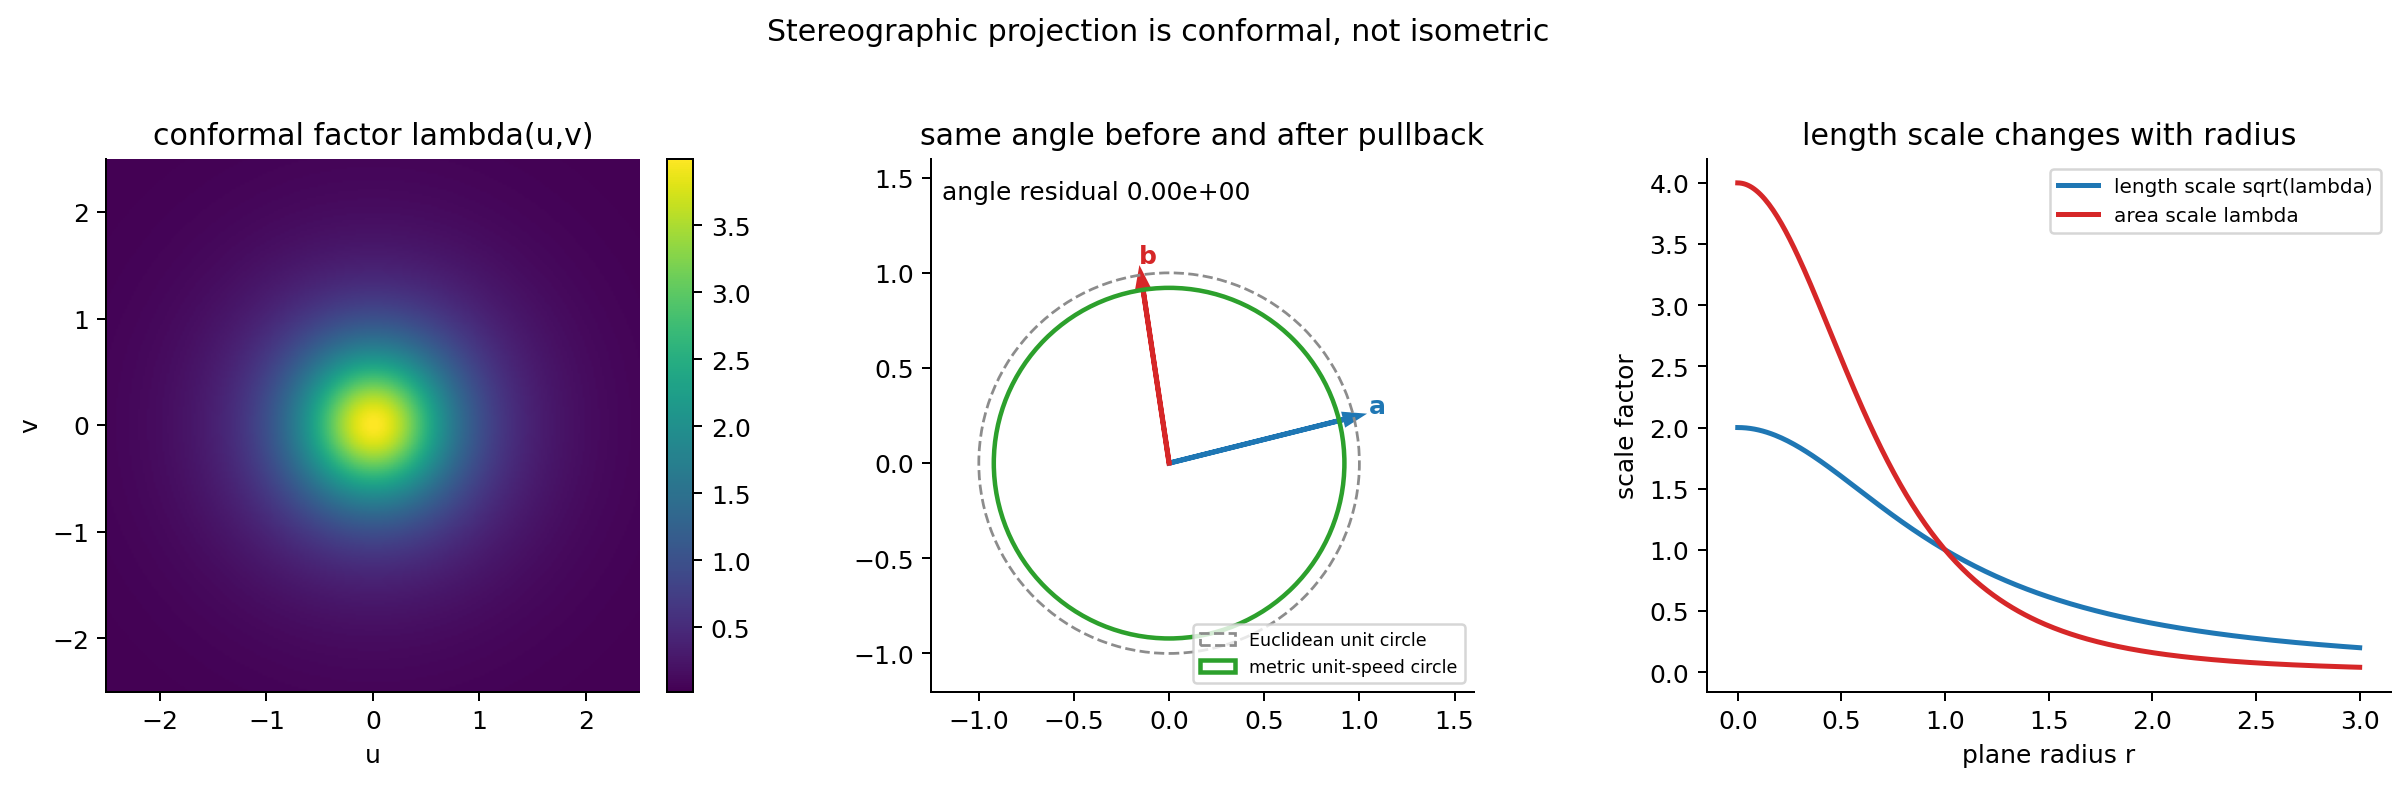

{'sample_u': 0.8,
 'sample_v': -0.45,
 'lambda': 1.1782704830356663,
 'metric_minus_lambda_identity_norm': 0.0,
 'angle_residual': 0.0}

In [5]:
def stereographic_inverse(u, v):
    r2 = u * u + v * v
    denom = r2 + 1.0
    return np.array([2 * u / denom, 2 * v / denom, (r2 - 1.0) / denom])


def stereographic_lambda(u, v):
    return 4.0 / (1.0 + u * u + v * v) ** 2


u0, v0 = 0.8, -0.45
lambda0 = stereographic_lambda(u0, v0)
M_stereo = metric_matrix(lambda0, 0.0, lambda0)
angle_a = np.array([1.0, 0.25])
angle_b = np.array([-0.15, 1.0])
plane_angle = angle_from_metric(np.eye(2), angle_a, angle_b)
sphere_angle = angle_from_metric(M_stereo, angle_a, angle_b)
conformal_angle_residual = abs(plane_angle - sphere_angle)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

grid = np.linspace(-2.5, 2.5, 240)
UU, VV = np.meshgrid(grid, grid)
LAM = stereographic_lambda(UU, VV)
im = axes[0].imshow(LAM, origin="lower", extent=[grid.min(), grid.max(), grid.min(), grid.max()], cmap="viridis")
axes[0].set_title("conformal factor lambda(u,v)")
axes[0].set_xlabel("u")
axes[0].set_ylabel("v")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].set_aspect("equal")
axes[1].set_title("same angle before and after pullback")
origin = np.array([0.0, 0.0])
for vec, color, label in [(angle_a, "#1f77b4", "a"), (angle_b, "#d62728", "b")]:
    axes[1].arrow(origin[0], origin[1], vec[0], vec[1], head_width=0.05, length_includes_head=True, color=color, lw=2)
    axes[1].text(vec[0] * 1.05, vec[1] * 1.05, label, color=color, weight="bold")
unit = Ellipse((0, 0), 2, 2, fill=False, color="0.55", lw=1.1, ls="--", label="Euclidean unit circle")
metric_unit = Ellipse((0, 0), 2 / np.sqrt(lambda0), 2 / np.sqrt(lambda0), fill=False, color="#2ca02c", lw=1.8, label="metric unit-speed circle")
axes[1].add_patch(unit)
axes[1].add_patch(metric_unit)
axes[1].set_xlim(-1.25, 1.6)
axes[1].set_ylim(-1.2, 1.6)
axes[1].legend(fontsize=7, loc="lower right")
axes[1].text(0.02, 0.96, f"angle residual {conformal_angle_residual:.2e}", transform=axes[1].transAxes, va="top")

axes[2].set_title("length scale changes with radius")
radii = np.linspace(0, 3.0, 300)
scale = 2 / (1 + radii ** 2)
area_scale = scale ** 2
axes[2].plot(radii, scale, label="length scale sqrt(lambda)", color="#1f77b4", lw=2)
axes[2].plot(radii, area_scale, label="area scale lambda", color="#d62728", lw=2)
axes[2].set_xlabel("plane radius r")
axes[2].set_ylabel("scale factor")
axes[2].legend(fontsize=8)

fig.suptitle("Stereographic projection is conformal, not isometric", y=1.03)
fig.tight_layout()
conformal_fig_path = FIGURES / "stereographic-conformal-factor.png"
fig.savefig(conformal_fig_path, bbox_inches="tight")
plt.close(fig)

conformal_checks = {
    "sample_u": u0,
    "sample_v": v0,
    "lambda": lambda0,
    "metric_minus_lambda_identity_norm": float(np.linalg.norm(M_stereo - lambda0 * np.eye(2))),
    "angle_residual": conformal_angle_residual,
}
write_json(CHECKS / "conformal-checks.json", conformal_checks)

display_artifact(conformal_fig_path, width=1000)
conformal_checks


## Equiareal Map: Archimedes' Sphere To Cylinder Theorem

Use latitude-longitude coordinates on the unit sphere:

$$\sigma_1(\theta,\phi)=(\cos\theta\cos\phi,\cos\theta\sin\phi,\sin\theta).$$

Archimedes' horizontal projection to the unit cylinder is

$$\sigma_2(\theta,\phi)=(\cos\phi,\sin\phi,\sin\theta).$$

The metrics are different:

$$M_1=\begin{pmatrix}1&0\\0&\cos^2\theta\end{pmatrix},\qquad
M_2=\begin{pmatrix}\cos^2\theta&0\\0&1\end{pmatrix}.$$

Their determinants are the same. That is the whole equiareal mechanism.


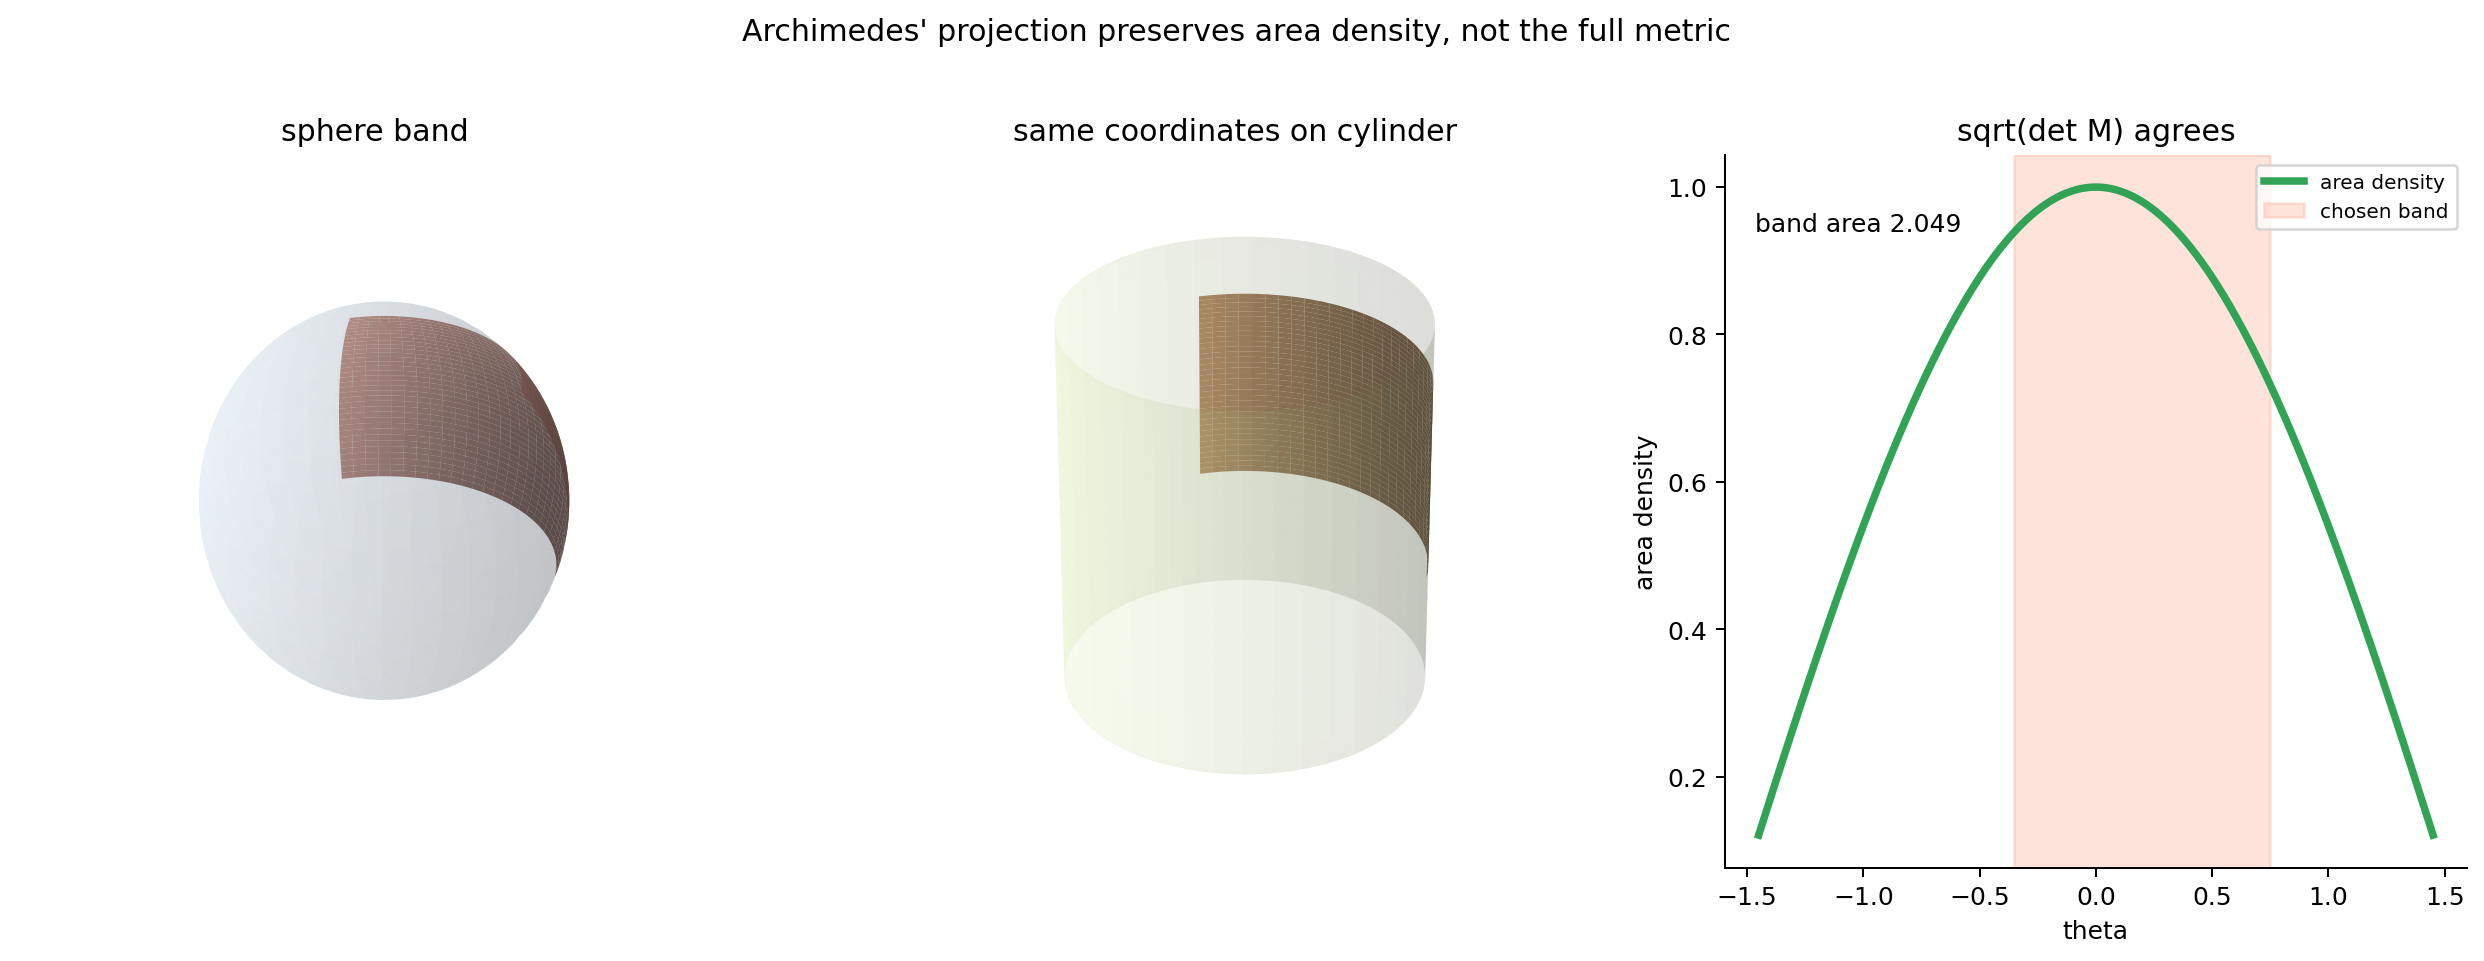

{'theta_sample': 0.6,
 'sphere_metric': [[1.0, 0.0], [0.0, 0.6811788772383368]],
 'cylinder_metric': [[0.6811788772383368, 0.0], [0.0, 1.0]],
 'metric_difference_norm_nonzero': 0.45088115578056154,
 'determinant_residual': np.float64(0.0),
 'band_area_sphere': np.float64(2.049073134957571),
 'band_area_cylinder': np.float64(2.049073134957571),
 'band_area_residual': np.float64(0.0)}

In [6]:
theta1, theta2 = -0.35, 0.75
phi1, phi2 = 0.35, 2.35
sphere_band_area = (phi2 - phi1) * (np.sin(theta2) - np.sin(theta1))
cylinder_band_area = (phi2 - phi1) * (np.sin(theta2) - np.sin(theta1))
archimedes_area_residual = abs(sphere_band_area - cylinder_band_area)

theta_sample = 0.6
M_sphere_arch = metric_matrix(1, 0, np.cos(theta_sample) ** 2)
M_cylinder_arch = metric_matrix(np.cos(theta_sample) ** 2, 0, 1)
archimedes_det_residual = abs(np.linalg.det(M_sphere_arch) - np.linalg.det(M_cylinder_arch))
archimedes_metric_residual = float(np.linalg.norm(M_sphere_arch - M_cylinder_arch))

fig = plt.figure(figsize=(14, 5.2))
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
th = np.linspace(-np.pi / 2, np.pi / 2, 70)
ph = np.linspace(0, 2 * np.pi, 120)
TH, PH = np.meshgrid(th, ph, indexing="ij")
X = np.cos(TH) * np.cos(PH)
Y = np.cos(TH) * np.sin(PH)
Z = np.sin(TH)
ax1.plot_surface(X, Y, Z, color="#c6dbef", alpha=0.18, edgecolor="none")
thb = np.linspace(theta1, theta2, 35)
phb = np.linspace(phi1, phi2, 55)
THB, PHB = np.meshgrid(thb, phb, indexing="ij")
ax1.plot_surface(np.cos(THB) * np.cos(PHB), np.cos(THB) * np.sin(PHB), np.sin(THB), color="#fc9272", alpha=0.85, edgecolor="none")
ax1.set_title("sphere band")
ax1.set_axis_off()
ax1.set_box_aspect((1, 1, 1))

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(np.cos(PH), np.sin(PH), np.sin(TH), color="#d9f0a3", alpha=0.18, edgecolor="none")
ax2.plot_surface(np.cos(PHB), np.sin(PHB), np.sin(THB), color="#fdae6b", alpha=0.85, edgecolor="none")
ax2.set_title("same coordinates on cylinder")
ax2.set_axis_off()
ax2.set_box_aspect((1, 1, 1))

ax3 = fig.add_subplot(1, 3, 3)
theta_line = np.linspace(-1.45, 1.45, 400)
ax3.plot(theta_line, np.abs(np.cos(theta_line)), color="#31a354", lw=3, label="area density")
ax3.axvspan(theta1, theta2, color="#fc9272", alpha=0.25, label="chosen band")
ax3.set_title("sqrt(det M) agrees")
ax3.set_xlabel("theta")
ax3.set_ylabel("area density")
ax3.legend(fontsize=8)
ax3.text(0.04, 0.92, f"band area {sphere_band_area:.3f}", transform=ax3.transAxes, va="top")

fig.suptitle("Archimedes' projection preserves area density, not the full metric", y=1.02)
fig.tight_layout()
archimedes_fig_path = FIGURES / "archimedes-equiareal-bands.png"
fig.savefig(archimedes_fig_path, bbox_inches="tight")
plt.close(fig)

archimedes_checks = {
    "theta_sample": theta_sample,
    "sphere_metric": M_sphere_arch.tolist(),
    "cylinder_metric": M_cylinder_arch.tolist(),
    "metric_difference_norm_nonzero": archimedes_metric_residual,
    "determinant_residual": archimedes_det_residual,
    "band_area_sphere": sphere_band_area,
    "band_area_cylinder": cylinder_band_area,
    "band_area_residual": archimedes_area_residual,
}
write_json(CHECKS / "archimedes-checks.json", archimedes_checks)

display_artifact(archimedes_fig_path, width=1000)
archimedes_checks


## Spherical Distance And Spherical Triangles

On the unit sphere, the first fundamental form gives the usual great-circle metric. For unit vectors `p` and `q`, the spherical distance is the central angle

$$d(p,q)=\arccos(p\cdot q).$$

This lets a triangle be computed from its vertices in `R^3`: sides are central angles, angles are angles between tangent directions, and area is the spherical excess `alpha+beta+gamma-pi`.


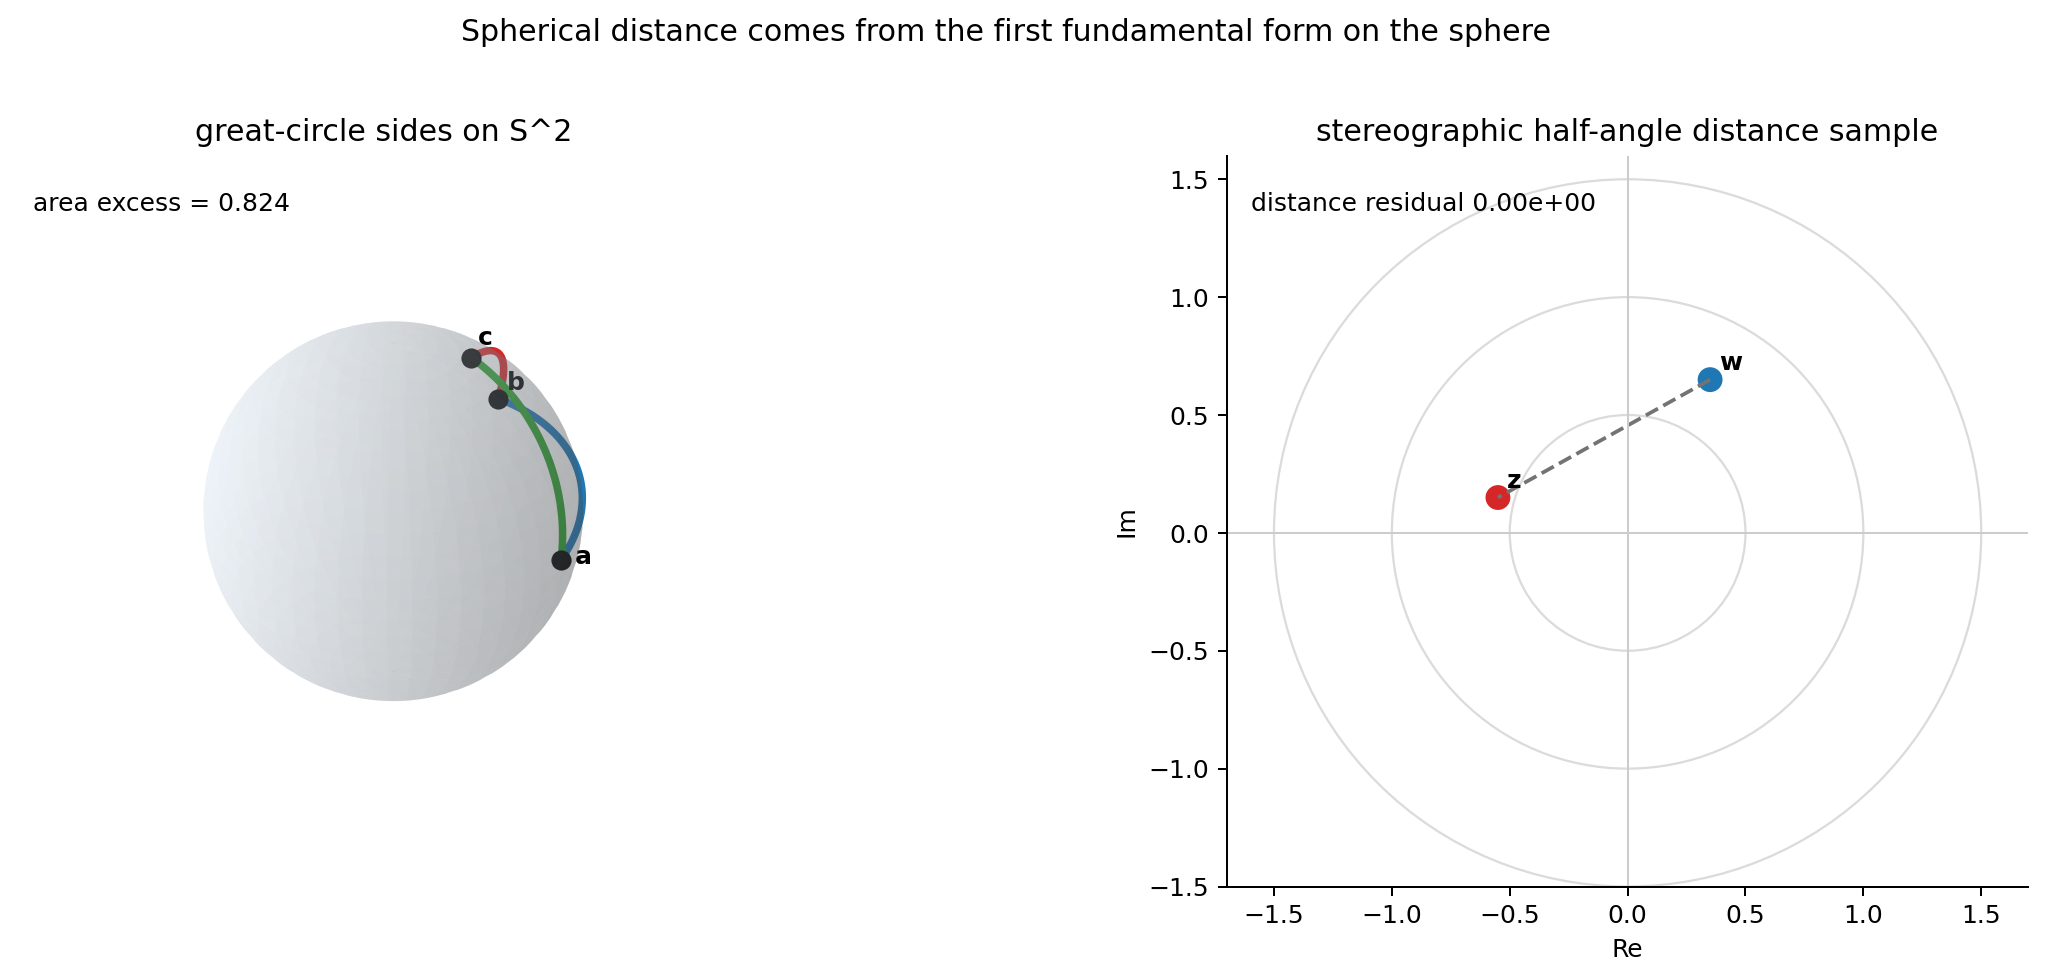

{'triangle_sides': {'A': 1.096932250403724,
  'B': 1.2148763619815426,
  'C': 1.4703310965814382},
 'triangle_angles': {'alpha': 1.1019773407951803,
  'beta': 1.2218676644797486,
  'gamma': 1.6412495269360594},
 'area_excess': 0.8235018786211952,
 'solid_angle_area': 0.8235018786211951,
 'cosine_rule_residual': np.float64(1.6653345369377348e-16),
 'sine_rule_residual': 2.220446049250313e-16,
 'excess_residual': 1.1102230246251565e-16,
 'stereographic_distance_direct': 1.6064025554365953,
 'stereographic_distance_formula': 1.6064025554365953,
 'stereographic_distance_residual': 0.0}

In [7]:
def normalize(v):
    v = np.asarray(v, dtype=float)
    return v / np.linalg.norm(v)


def spherical_distance(p, q):
    p = normalize(p)
    q = normalize(q)
    return float(np.arccos(np.clip(np.dot(p, q), -1.0, 1.0)))


def great_circle_arc(p, q, n=120):
    p = normalize(p)
    q = normalize(q)
    d = spherical_distance(p, q)
    if d < 1e-12:
        return np.repeat(p[None, :], n, axis=0)
    t = np.linspace(0, 1, n)
    return (np.sin((1 - t) * d)[:, None] * p + np.sin(t * d)[:, None] * q) / np.sin(d)


def tangent_direction_at(p, q):
    p = normalize(p)
    q = normalize(q)
    tangent = q - np.dot(q, p) * p
    return normalize(tangent)


def spherical_triangle_data(a, b, c):
    a, b, c = normalize(a), normalize(b), normalize(c)
    A = spherical_distance(b, c)
    B = spherical_distance(c, a)
    C = spherical_distance(a, b)
    alpha = spherical_distance(tangent_direction_at(a, b), tangent_direction_at(a, c))
    beta = spherical_distance(tangent_direction_at(b, c), tangent_direction_at(b, a))
    gamma = spherical_distance(tangent_direction_at(c, a), tangent_direction_at(c, b))
    excess = alpha + beta + gamma - np.pi
    solid_angle = 2 * math.atan2(abs(np.linalg.det(np.vstack([a, b, c]))), 1 + np.dot(a, b) + np.dot(b, c) + np.dot(c, a))
    cos_rule_residual = abs(np.cos(gamma) - (np.cos(C) - np.cos(A) * np.cos(B)) / (np.sin(A) * np.sin(B)))
    sine_values = np.array([np.sin(alpha) / np.sin(A), np.sin(beta) / np.sin(B), np.sin(gamma) / np.sin(C)])
    sine_rule_residual = float(np.max(sine_values) - np.min(sine_values))
    excess_residual = abs(excess - solid_angle)
    return {
        "vertices": [a, b, c],
        "sides": {"A": A, "B": B, "C": C},
        "angles": {"alpha": alpha, "beta": beta, "gamma": gamma},
        "area_excess": excess,
        "solid_angle_area": solid_angle,
        "cosine_rule_residual": cos_rule_residual,
        "sine_rule_residual": sine_rule_residual,
        "excess_residual": excess_residual,
    }


a = normalize([1.0, 0.0, 0.0])
b = normalize([0.1, 0.96, 0.25])
c = normalize([0.35, 0.2, 0.92])
tri = spherical_triangle_data(a, b, c)


def stereographic_point(w):
    u = float(np.real(w))
    v = float(np.imag(w))
    return stereographic_inverse(u, v)


w = 0.35 + 0.65j
z = -0.55 + 0.15j
sphere_distance_direct = spherical_distance(stereographic_point(w), stereographic_point(z))
sphere_distance_formula = 2 * math.atan(abs(w - z) / abs(1 + np.conjugate(w) * z))
stereographic_distance_residual = abs(sphere_distance_direct - sphere_distance_formula)

fig = plt.figure(figsize=(14, 5.3))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
th = np.linspace(-np.pi / 2, np.pi / 2, 55)
ph = np.linspace(0, 2 * np.pi, 100)
TH, PH = np.meshgrid(th, ph, indexing="ij")
ax1.plot_surface(np.cos(TH) * np.cos(PH), np.cos(TH) * np.sin(PH), np.sin(TH), color="#deebf7", alpha=0.26, edgecolor="none")
for p, q, color in [(a, b, "#1f77b4"), (b, c, "#d62728"), (c, a, "#2ca02c")]:
    arc = great_circle_arc(p, q)
    ax1.plot(arc[:, 0], arc[:, 1], arc[:, 2], color=color, lw=3)
for label, p in [("a", a), ("b", b), ("c", c)]:
    ax1.scatter([p[0]], [p[1]], [p[2]], s=50, color="black")
    ax1.text(p[0] * 1.08, p[1] * 1.08, p[2] * 1.08, label, fontsize=10, weight="bold")
ax1.set_title("great-circle sides on S^2")
ax1.set_axis_off()
ax1.set_box_aspect((1, 1, 1))
ax1.text2D(0.02, 0.95, f"area excess = {tri['area_excess']:.3f}", transform=ax1.transAxes, va="top")

ax2 = fig.add_subplot(1, 2, 2)
ax2.set_aspect("equal")
ax2.set_title("stereographic half-angle distance sample")
ax2.scatter([w.real, z.real], [w.imag, z.imag], s=80, color=["#1f77b4", "#d62728"])
ax2.plot([w.real, z.real], [w.imag, z.imag], color="0.45", ls="--")
for label, val in [("w", w), ("z", z)]:
    ax2.text(val.real + 0.04, val.imag + 0.04, label, weight="bold")
for r in [0.5, 1.0, 1.5]:
    circle = plt.Circle((0, 0), r, fill=False, color="0.86", lw=0.9)
    ax2.add_patch(circle)
ax2.axhline(0, color="0.8", lw=0.8)
ax2.axvline(0, color="0.8", lw=0.8)
ax2.set_xlim(-1.7, 1.7)
ax2.set_ylim(-1.5, 1.6)
ax2.set_xlabel("Re")
ax2.set_ylabel("Im")
ax2.text(0.03, 0.95, f"distance residual {stereographic_distance_residual:.2e}", transform=ax2.transAxes, va="top")

fig.suptitle("Spherical distance comes from the first fundamental form on the sphere", y=1.02)
fig.tight_layout()
spherical_fig_path = FIGURES / "spherical-distance-triangle.png"
fig.savefig(spherical_fig_path, bbox_inches="tight")
plt.close(fig)

spherical_checks = {
    "triangle_sides": tri["sides"],
    "triangle_angles": tri["angles"],
    "area_excess": tri["area_excess"],
    "solid_angle_area": tri["solid_angle_area"],
    "cosine_rule_residual": tri["cosine_rule_residual"],
    "sine_rule_residual": tri["sine_rule_residual"],
    "excess_residual": tri["excess_residual"],
    "stereographic_distance_direct": sphere_distance_direct,
    "stereographic_distance_formula": sphere_distance_formula,
    "stereographic_distance_residual": stereographic_distance_residual,
}
write_json(CHECKS / "spherical-checks.json", spherical_checks)

display_artifact(spherical_fig_path, width=1000)
spherical_checks


## Applied Lab: Classify A Surface Map From Its Metric Data

The lab below turns the main definitions into a reusable diagnostic. Given an original metric matrix `M1` and a target pulled-back metric matrix `M2`, it asks three questions:

- Are the matrices equal? Then the map is locally isometric.
- Is `M2 = lambda M1` for a scalar `lambda`? Then it is conformal.
- Do the determinants agree? Then it is equiareal.

This deliberately includes maps that satisfy one test but fail another, because that is the fastest way to separate the Chapter 6 definitions.


In [8]:
def classify_metric_map(M1, M2, *, tol=1e-9):
    M1 = np.asarray(M1, dtype=float)
    M2 = np.asarray(M2, dtype=float)
    isometry = bool(np.linalg.norm(M2 - M1) < tol)
    A = np.linalg.solve(M1, M2)
    lam = float(np.trace(A) / 2.0)
    conformal_residual = float(np.linalg.norm(A - lam * np.eye(2)))
    conformal = bool(lam > 0 and conformal_residual < tol)
    area_factor = float(np.sqrt(np.linalg.det(M2) / np.linalg.det(M1)))
    equiareal = bool(abs(area_factor - 1.0) < tol)
    return {
        "isometry": isometry,
        "conformal": conformal,
        "equiareal": equiareal,
        "lambda_if_conformal": lam if conformal else np.nan,
        "conformal_residual": conformal_residual,
        "area_factor": area_factor,
        "metric_difference_norm": float(np.linalg.norm(M2 - M1)),
    }


lab_cases = [
    ("plane to cylinder wrap", np.eye(2), np.eye(2)),
    ("plane dilation by 1.40", np.eye(2), (1.40 ** 2) * np.eye(2)),
    ("stereographic inverse at (0.8,-0.45)", np.eye(2), M_stereo),
    ("Archimedes sphere to cylinder at theta=0.6", M_sphere_arch, M_cylinder_arch),
]
lab_rows = []
for name, M1, M2 in lab_cases:
    row = {"map": name}
    row.update(classify_metric_map(M1, M2))
    lab_rows.append(row)
lab_table = pd.DataFrame(lab_rows)
classifier_csv_path = TABLES / "map-classifier-table.csv"
lab_table.to_csv(classifier_csv_path, index=False)

display(lab_table)
display_artifact(classifier_csv_path)


,map,isometry,conformal,equiareal,lambda_if_conformal,conformal_residual,area_factor,metric_difference_norm
0,plane to cylinder wrap,True,True,True,1.00000,0.000000,1.00000,0.000000
1,plane dilation by 1.40,False,True,False,1.96000,0.000000,1.96000,1.357645
2,"stereographic inverse at (0.8,-0.45)",False,True,False,1.17827,0.000000,1.17827,0.252113
3,Archimedes sphere to cylinder at theta=0.6,False,False,True,NaN,0.556397,1.00000,0.450881


## Final Sanity Checks

The final cell checks the core identities and the generated artifact set. The variable is named `final_sanity` on purpose so automated and human review can find the chapter's closing validation block quickly.


In [9]:
new_artifacts = [
    metric_fig_path,
    length_fig_path,
    cylinder_html_path,
    conformal_fig_path,
    archimedes_fig_path,
    spherical_fig_path,
    metric_csv_path,
    classifier_csv_path,
    source_span_path,
    storyboard_path,
    CHECKS / "curve-length-checks.json",
    CHECKS / "conformal-checks.json",
    CHECKS / "archimedes-checks.json",
    CHECKS / "spherical-checks.json",
]

for artifact in new_artifacts:
    suffix = artifact.suffix.lower()
    min_bytes = 5000 if suffix in {".png", ".html"} else 40
    assert_artifact(artifact, min_bytes=min_bytes)

notebook_text = NOTEBOOK_PATH.read_text(encoding="utf-8")
generic_builder_token = "build" + "_unit" + "_visuals"
has_generic_builder = generic_builder_token in notebook_text
assert not has_generic_builder

assert area_identity == 0
assert cylinder_length_residual < 2.5e-4
assert conformal_checks["metric_minus_lambda_identity_norm"] < 1e-12
assert conformal_checks["angle_residual"] < 1e-12
assert archimedes_checks["determinant_residual"] < 1e-12
assert archimedes_checks["band_area_residual"] < 1e-12
assert spherical_checks["cosine_rule_residual"] < 1e-12
assert spherical_checks["sine_rule_residual"] < 1e-12
assert spherical_checks["excess_residual"] < 1e-12
assert spherical_checks["stereographic_distance_residual"] < 1e-12
assert lab_table.loc[lab_table["map"] == "plane to cylinder wrap", "isometry"].iloc[0]
assert not lab_table.loc[lab_table["map"] == "Archimedes sphere to cylinder at theta=0.6", "isometry"].iloc[0]
assert lab_table.loc[lab_table["map"] == "Archimedes sphere to cylinder at theta=0.6", "equiareal"].iloc[0]

lab_records = json.loads(lab_table.to_json(orient="records"))

final_sanity = {
    "source_span": SOURCE_SPAN,
    "artifact_count": len(new_artifacts),
    "artifacts": [str(path.relative_to(BOOK_ROOT)).replace("\\", "/") for path in new_artifacts],
    "no_generic_visual_builder": not has_generic_builder,
    "residuals": {
        "cross_product_area_identity": 0,
        "plane_cylinder_curve_length": cylinder_length_residual,
        "stereographic_metric_scalar": conformal_checks["metric_minus_lambda_identity_norm"],
        "stereographic_angle": conformal_checks["angle_residual"],
        "archimedes_det": archimedes_checks["determinant_residual"],
        "archimedes_band_area": archimedes_checks["band_area_residual"],
        "spherical_cosine_rule": spherical_checks["cosine_rule_residual"],
        "spherical_sine_rule": spherical_checks["sine_rule_residual"],
        "spherical_excess": spherical_checks["excess_residual"],
        "stereographic_distance": spherical_checks["stereographic_distance_residual"],
    },
    "lab_cases": lab_records,
}
final_sanity_path = write_json(CHECKS / "final-sanity.json", final_sanity)
final_sanity_underscore_path = write_json(CHECKS / "final_sanity.json", final_sanity)
for artifact in [final_sanity_path, final_sanity_underscore_path]:
    assert_artifact(artifact, min_bytes=80)

final_sanity


{'source_span': {'printed_pages': '121-158',
  'pdf_pages': '127-163',
  'sections': '6.1-6.5',
  'source_use': 'orientation only; no copied prose, figures, screenshots, hints, or solutions'},
 'artifact_count': 14,
 'artifacts': ['artifacts/chapter-06/figures/metric-coefficients-rulers.png',
  'artifacts/chapter-06/figures/surface-curve-lengths-and-cylinder-isometry.png',
  'artifacts/chapter-06/interactive/local-isometry-cylinder-wrap.html',
  'artifacts/chapter-06/figures/stereographic-conformal-factor.png',
  'artifacts/chapter-06/figures/archimedes-equiareal-bands.png',
  'artifacts/chapter-06/figures/spherical-distance-triangle.png',
  'artifacts/chapter-06/tables/metric-samples.csv',
  'artifacts/chapter-06/tables/map-classifier-table.csv',
  'artifacts/chapter-06/checks/source-span.json',
  'artifacts/chapter-06/checks/visual-storyboard.json',
  'artifacts/chapter-06/checks/curve-length-checks.json',
  'artifacts/chapter-06/checks/conformal-checks.json',
  'artifacts/chapter-06

## Takeaways

- The first fundamental form is the metric tensor of a surface patch written in two coordinates.
- `E`, `F`, and `G` control every first-order measurement in the chapter: speed, length, angle, and area density.
- A local isometry preserves the whole metric matrix, not just area or angles.
- A conformal map preserves angle because it rescales the metric by one scalar in all tangent directions.
- An equiareal map preserves `sqrt(EG-F^2)` but may distort lengths and angles.
- Archimedes' theorem is the determinant test in a classical disguise: sphere and cylinder have different matrices with the same determinant.
- Spherical distance and spherical triangle laws are not new measuring rules; they are the first fundamental form of the unit sphere applied to great-circle arcs.
